# The *Real* Fundamentals of Matplotlib

In [1]:
print("Let’s take a look!")

Let’s take a look!


## The Plot Process

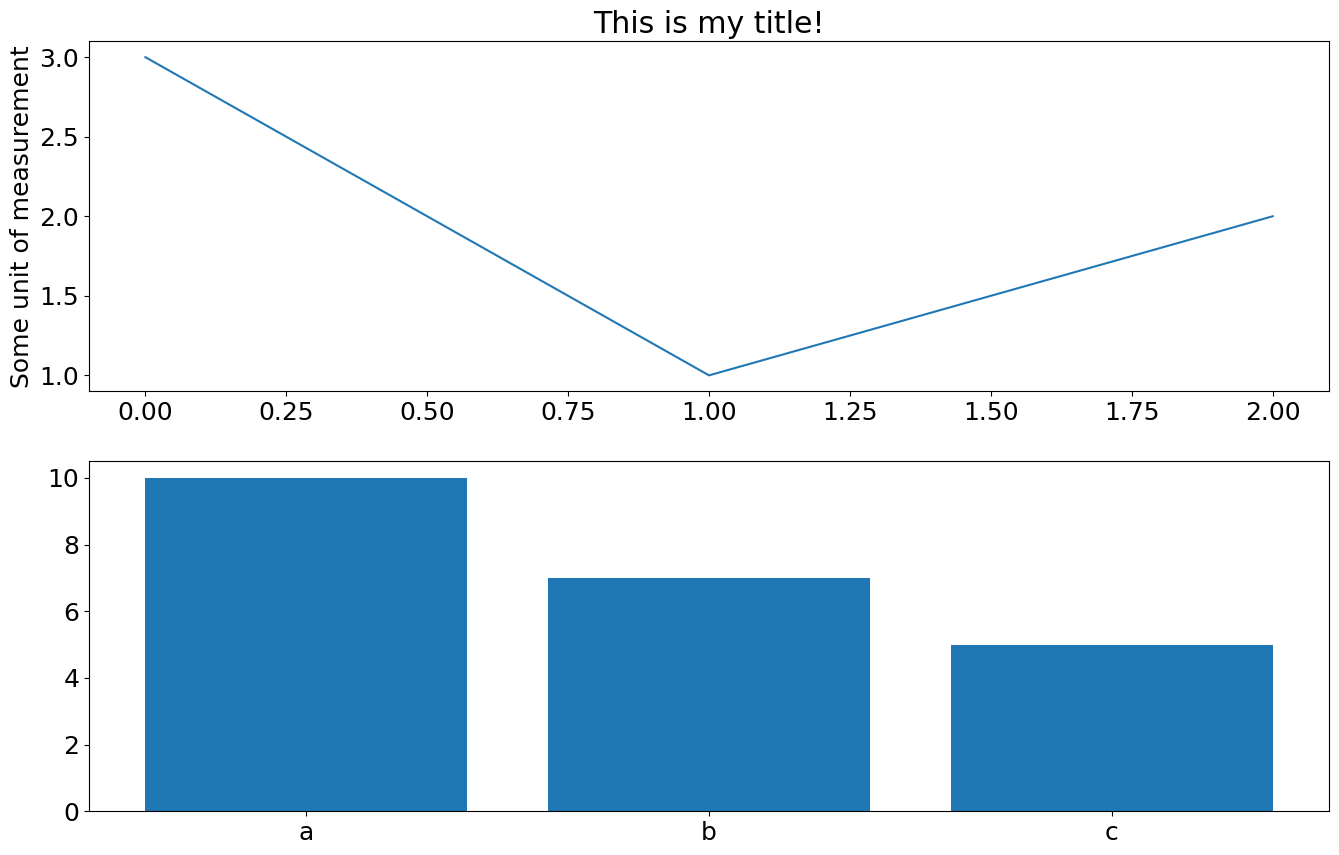

In [2]:
import matplotlib.pyplot as plt

# ① set global configuration; https://matplotlib.org/stable/users/explain/customizing.html#matplotlibrc-sample
plt.rc('font', size=18)

# ② create a figure and some Axes (or subfigures)
#   usually accomplished via pyplot.subplots or pyplot.subplot_mosaic
fig, axes = plt.subplots(nrows=2, ncols=1)


# mosaic = [
#     ['A', 'A'],
#     ['B', 'C']
# ]
# fig, axes = plt.subplot_mosaic(mosaic)

# ③ put some data on your chart
axes[0].plot([0, 1, 2], [3, 1, 2])
axes[1].bar(['a', 'b', 'c'], [10, 7, 5])

# ④ add labels/annotations
axes[0].set_title('This is my title!')
axes[0].set_ylabel('Some unit of measurement')

# ⑤ save as an image, or view interactively
# fig.savefig('/tmp/plot.png')
plt.show()

## The Object-Oriented Interface

Matplotlib has been around for 20+ years and its API has changed many
times over the years. Has backwards compatibility gone too far?

Two interfaces:
- an implicit global API (matlab style)
- an explicit OO API (Python style)

**The implicit global API**

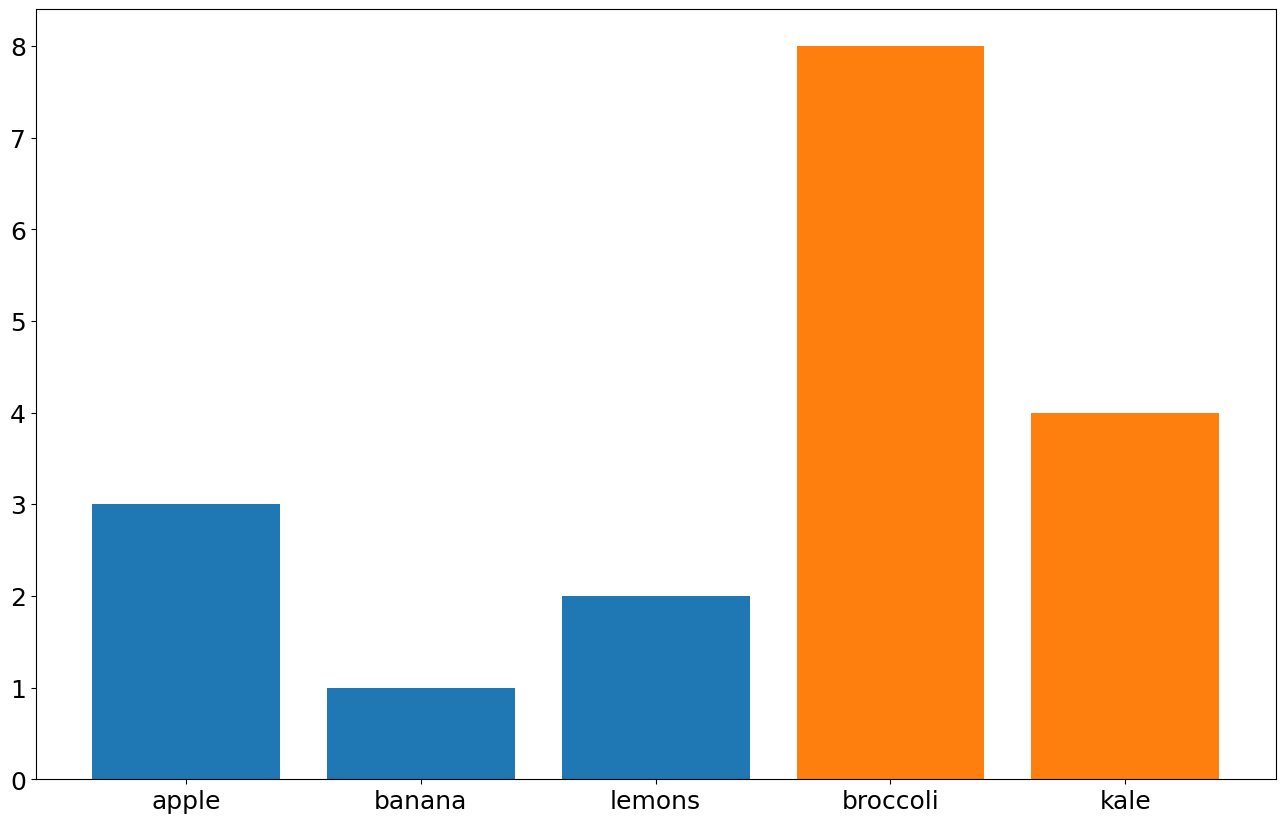

In [3]:
import matplotlib.pyplot as plt

plt.bar(['apple', 'banana', 'lemons'], [3, 1, 2])

# what if we want to plot vegetables on a separate chart?
plt.bar(['broccoli', 'kale'], [8, 4])

plt.show()

Instead, we can reach for the **explicit object-oriented interface**.

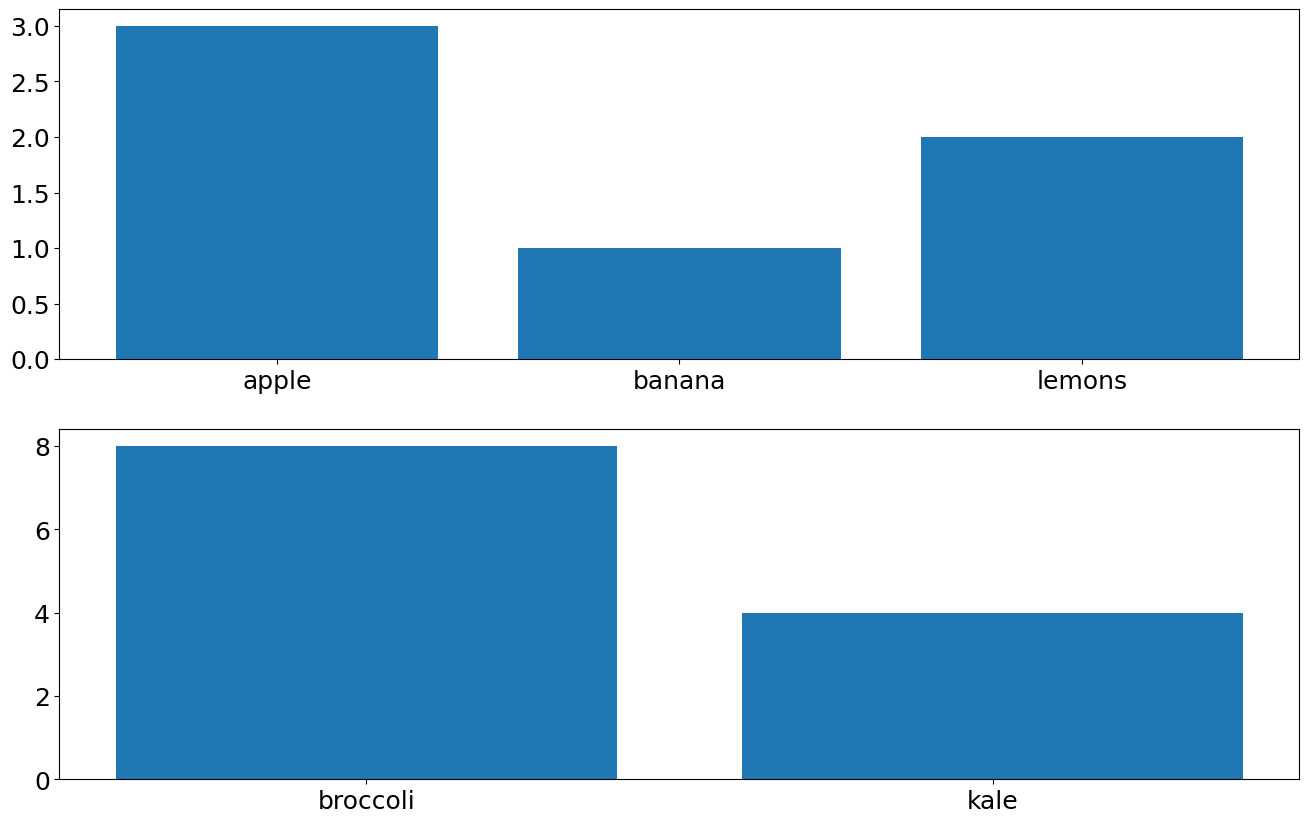

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2)
axes[0].bar(['apple', 'banana', 'lemons'], [3, 1, 2]) # plot on a specific Axes

# what if we want to plot vegetables on a separate chart?
axes[1].bar(['broccoli', 'kale'], [8, 4])

plt.show()

An understanding of Object Orientation allows us to quickly explore and make
API guesses to customize your charts.

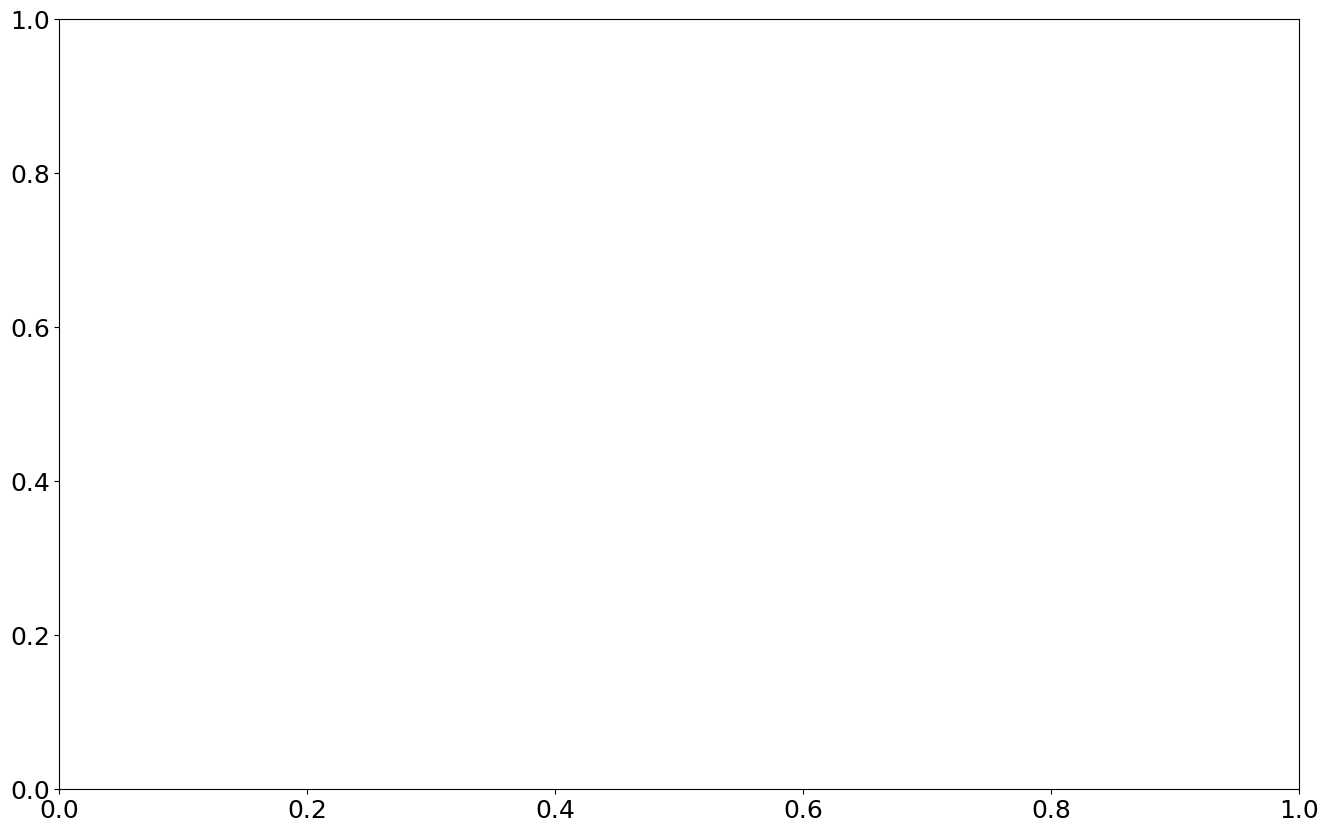

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# print(dir(ax))
# help(ax.set_xlabel)

**Rembember**
- A `Figure` has 0 or more `Axes`, `plt.subplots()` creates a Figure on our behalf and adds an Axes.
- Avoid the high-level namespace `pyplot` for anything more complex than a throwaway chart.
  You should reach for the pyplot interface when you want to:
    - set/update rc-params
    - create a Figure and Axes
    - `plt.show()` your figure in a GUI

## Coordinate Spaces

Matplotlib has a number of different coordinate spaces for you to plot in.
- data space
- proportional space
- pixels

An understanding of these systems
- Makes text labelling/annotating MUCH easier
- Place artists *exactly* where you want them

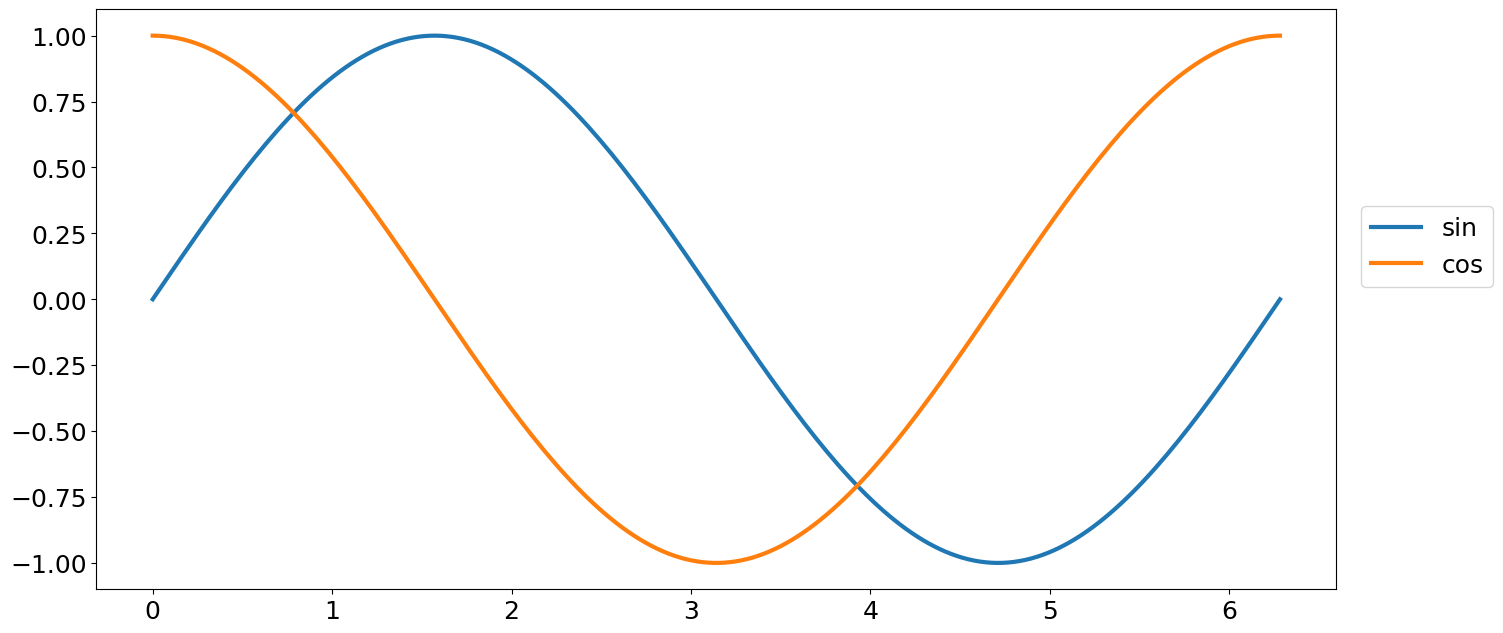

In [6]:
import matplotlib.pyplot as plt
from numpy import pi, linspace, sin, cos

xs = linspace(0, 2*pi, 200)
fig, ax = plt.subplots(gridspec_kw={'bottom': .3})
ax.plot(xs, sin(xs), label='sin', lw=3)
ax.plot(xs, cos(xs), label='cos', lw=3)

#                                              x  y
ax.legend(loc='lower left', bbox_to_anchor=(1.01, .5))

plt.show()

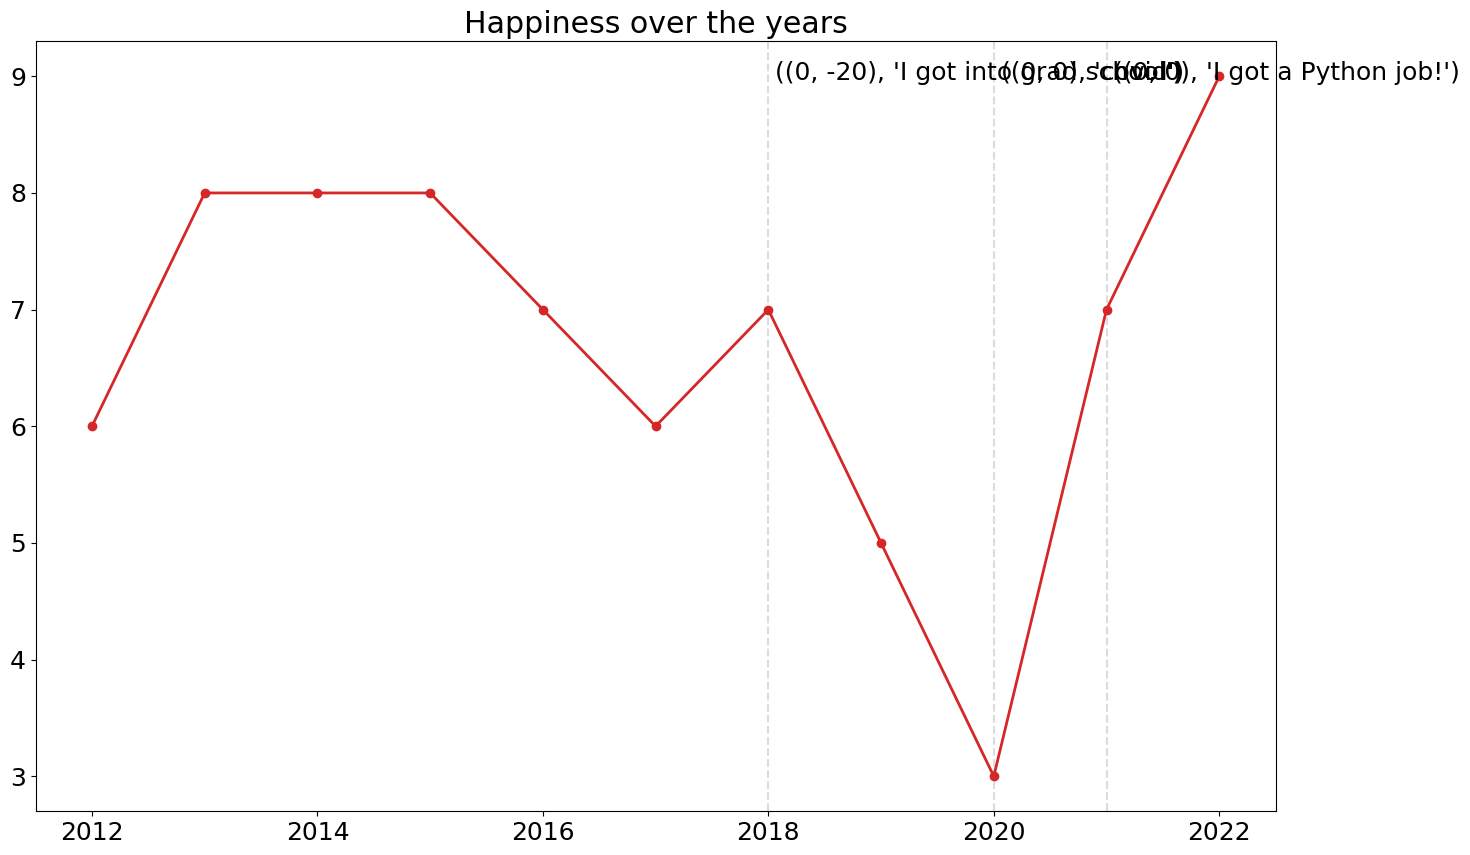

In [7]:
import matplotlib.pyplot as plt
from numpy import pi, linspace, sin, cos

data = [
    (2012, 6),
    (2013, 8),
    (2014, 8),
    (2015, 8),
    (2016, 7),
    (2017, 6),
    (2018, 7),
    (2019, 5),
    (2020, 3),
    (2021, 7),
    (2022, 9),
]

years, happiness = zip(*data)

fig, ax = plt.subplots()
ax.plot(years, happiness, lw=2, color='tab:red', marker='o')
ax.set_title('Happiness over the years')

key_events = {
    2018: ((0, -20), 'I got into grad school'),
    2020: ((0, 0), 'covid'), 2021: ((0, 0), 'I got a Python job!'),
}

# legend : bbox_to_anchor
# most plotting methods take a `transform`
# data: ax.transData
# prop: ax.transAxes
#    ax.transData, ax.transAxes
# blende_facotry(ax.transData, ax.transAxes)
ax.vlines(list(key_events), 0, 1, transform=ax.get_xaxis_transform(), color='gainsboro', ls='--', zorder=0)


for year, label in key_events.items():
    ax.annotate(
        label,
        xy=(year, .95), xycoords=ax.get_xaxis_transform(),
        xytext=(5, 0), textcoords='offset points',
    )

plt.show()

## TickLocators & TickFormatters

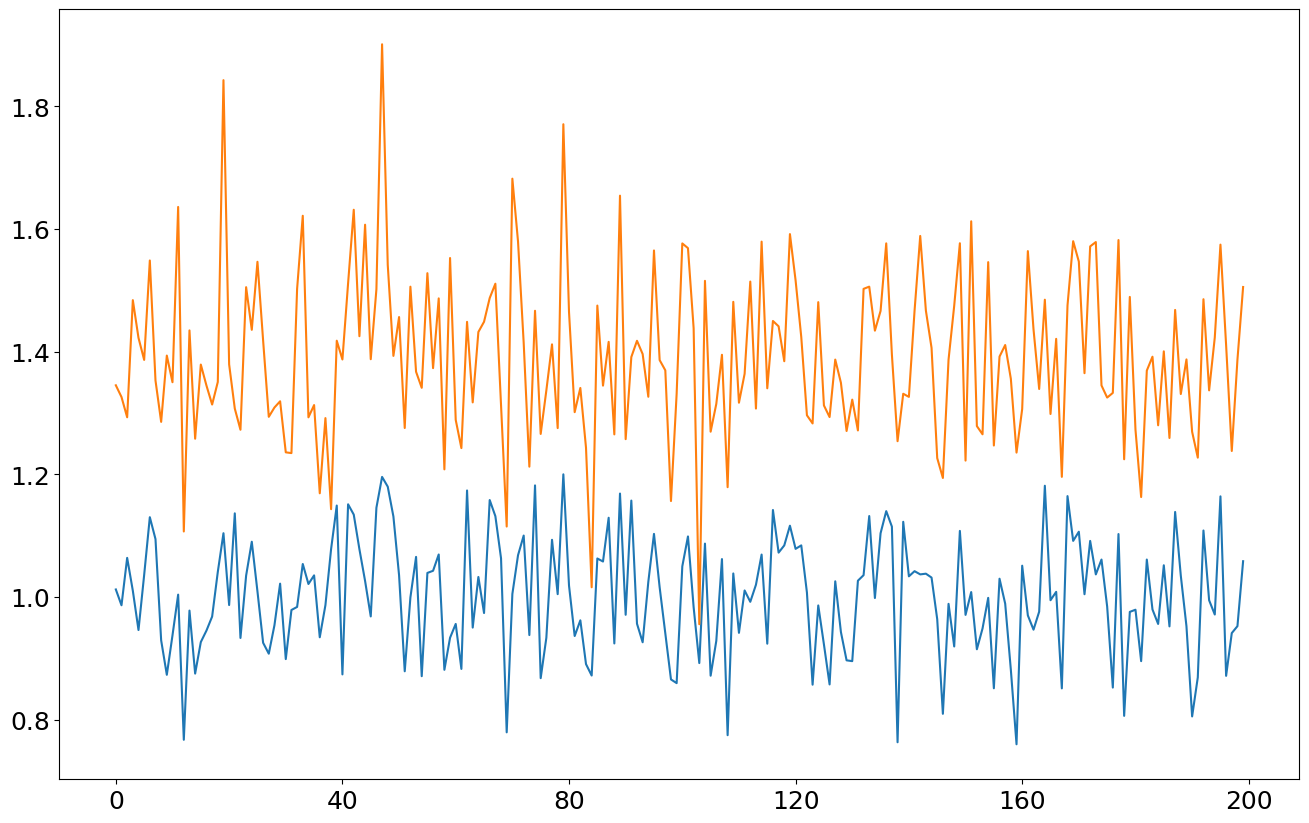

In [8]:
import matplotlib.pyplot as plt
from numpy import linspace
from numpy.random import default_rng

rnd = default_rng(0)
walks = rnd.normal(1, .1, size=(2, 200)).cumprod(axis=0)
walks[1] += .4

fig, ax = plt.subplots()
ax.plot(walks[0])
ax.plot(walks[1])

# min_x, max_x = ax.get_xlim()
# min_x, max_x = ax.dataLim.x0, ax.dataLim.x1
# ticks = linspace(min_x, max_x, 4)
# ax.set_xticks(ticks)

from matplotlib.ticker import MaxNLocator # Find a nice set of ticks for a maximum of N locations
ax.xaxis.set_major_locator(MaxNLocator(6))

plt.show()

Tick Locators: Compute the locations of the x/y ticks
Tick Formatters: Control the displayed text at each of the tick locations

**Some common Tick Locators**

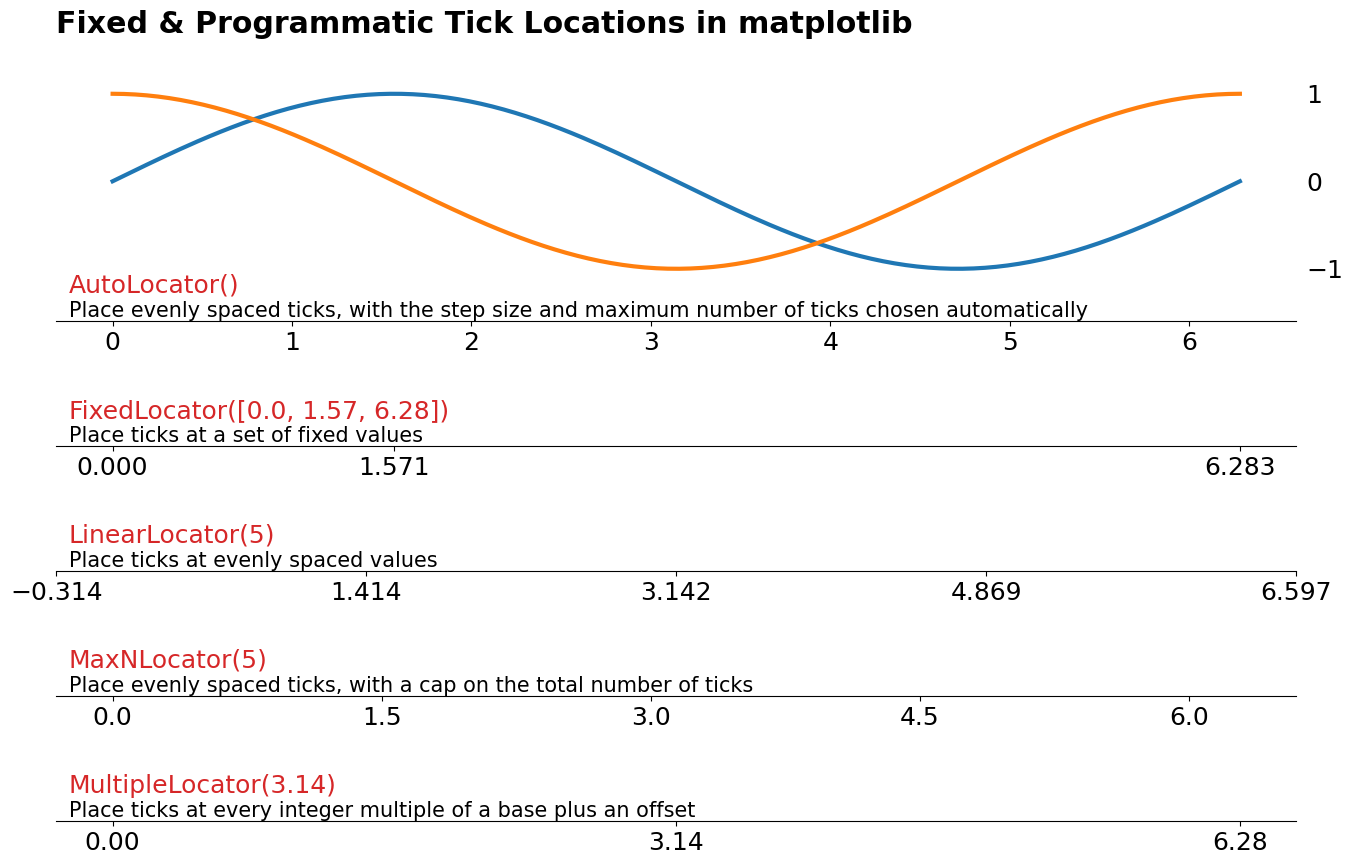

In [9]:
from functools import partial
from numpy import pi, sin, cos, linspace, round as np_round
from matplotlib.ticker import (
    AutoLocator, FixedLocator, LinearLocator,
    MaxNLocator, MultipleLocator, IndexLocator,
)
import matplotlib.pyplot as plt
from matplotlib.transforms import IdentityTransform, blended_transform_factory

plt.rc('axes.spines', bottom=True, left=False, right=False, top=False)

def twinner(orig_ax):
    yield orig_ax
    while True:
        child_ax = orig_ax.twiny()
        child_ax.set_xlim(*orig_ax.get_xlim())
        yield child_ax

locators = [
    partial(AutoLocator),
    partial(FixedLocator, [0, .5*pi, 2*pi]),
    partial(LinearLocator, 5),
    partial(MaxNLocator, 5),
    partial(MultipleLocator, pi),
]

xs = linspace(0, 2*pi, 200)
fig, ax = plt.subplots(gridspec_kw={'bottom': .6})
ax.plot(xs, sin(xs), label='sin', lw=3)
ax.plot(xs, cos(xs), label='cos', lw=3)
ax.yaxis.set_tick_params(labelleft=False, left=False, labelright=True)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.margins(y=.3)

offset = 0
for loc, ax in zip(locators, twinner(ax)):
    ax.xaxis.set_major_locator(loc())
    ax.xaxis.set_tick_params(labeltop=False, top=False, labelbottom=True, bottom=True)
    ax.spines['bottom'].set_position(('outward', offset))

    docs_text = ax.annotate(
        ' '.join(loc.func.__doc__.strip().split('.')[0].split()),
        xy=(.01, 0), xycoords=ax.spines['bottom'],
        xytext=(0, 4), textcoords='offset points',
        va='bottom',
        size='small',
    )

    args = tuple(type(arg)(np_round(arg, 2).tolist()) for arg in loc.args)
    arg_string = repr(args).removeprefix("(").removesuffix(")").removesuffix(",")
    ax.annotate(
        f'{loc.func.__name__}({arg_string})',
        xy=(0, 1), xycoords=docs_text,
        xytext=(0, 2), textcoords='offset points',
        va='bottom',
        color='tab:red',
    )
    offset += 90

ax.set_title('Fixed & Programmatic Tick Locations in matplotlib', loc='left', weight='semibold')

plt.show()

Formatters

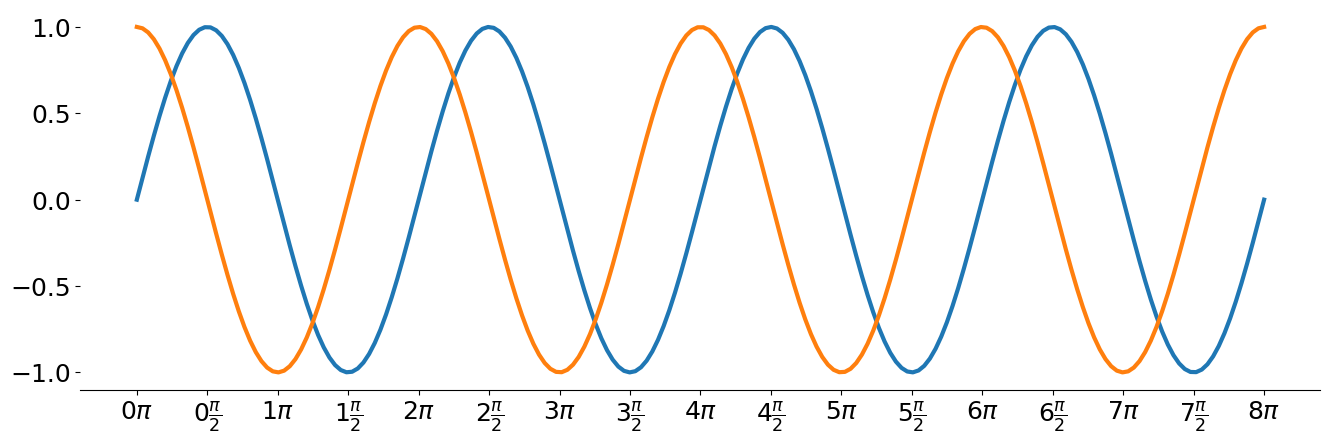

In [10]:
from functools import partial
from numpy import pi, sin, cos, linspace, round as np_round
from matplotlib.ticker import (
    AutoLocator, FixedLocator, LinearLocator,
    MaxNLocator, MultipleLocator, IndexLocator,
)
import matplotlib.pyplot as plt

plt.rc('axes.spines', bottom=True, left=False, right=False, top=False)

xs = linspace(0, 8*pi, 200)
fig, ax = plt.subplots(gridspec_kw={'bottom': .5})
ax.plot(xs, sin(xs), label='sin', lw=3)
ax.plot(xs, cos(xs), label='cos', lw=3)

ax.xaxis.set_major_locator(MultipleLocator(pi / 2))
# ax.xaxis.set_major_formatter(lambda x, pos: f'{round(x / pi, 2)}$\\pi$')

def pi_formatter(x, pos):
    from math import isclose
    whole, remainder = divmod(x, pi)
    whole = int(whole)
    if isclose(remainder, pi):
        whole += 1
        remainder = 0

    if remainder > 0:
        return f'${whole}\\frac{{\\pi}}{{2}}$'
    return f'${whole}{{\\pi}}$'
ax.xaxis.set_major_formatter(pi_formatter)

plt.show()

## The Anatomy of a Figure

```zsh
eog https://matplotlib.org/stable/_images/anatomy.png
```

The above image was retrieved from the
[Matplotlib Axes Intro](https://matplotlib.org/stable/users/explain/axes/axes_intro.html) docs.

## Wrap Up

Remember that matplotlib is incredibly flexible. It has 20+ years of
"historical baggage" which has resulted in a confusing API. But the principles
we covered today will elucidate the parts of the API that are worth commiting
to memory, and which are worth looking up each time you use it.

---

# HTML/JavaScript (bokeh, altair, plotly)
- GREAT for interactive viz
    - low level interace
    - high level interace
- If you’re new to plotting

# Matplotlib
There are no impossible walls, just confusing ones.